## How does the variant effect change along different annotations: AF, transition vs transversion, etc.?

In [16]:
import ast
import sys
import pandas as pd
import numpy as np  # For potential NaN handling if needed
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math


sys.path.append("../00_helpful_functions")
import helpful_functions as hf

### Transition vs transversion

In [ ]:
import pandas as pd

variant_effect_df_path = "data/80k_tested_variant_annotation_table_with_readout.tsv.gz"

variant_effect_df = pd.read_csv(
    variant_effect_df_path,
    sep="\t",
    compression="gzip",
)

# eval list like columns
example_row = variant_effect_df.iloc[0]
# get all columns which contain a "[" in the values
list_list_cols = []
for col in variant_effect_df.columns:
    if (
        example_row[col]
        and isinstance(example_row[col], str)
        and "[" in example_row[col]
    ):
        list_list_cols.append(col)

print(list_list_cols)

for col in list_list_cols:
    variant_effect_df[col] = (
        variant_effect_df[col].apply(hf.safe_eval)
    )

['enformer_classes_list', 'gene_set', 'region_gene_set']


In [24]:
# generate unique set of variants => take the max variant effect for each duplicated variant (by absolute effect size)
# sort and take first
variant_effect_df = variant_effect_df.sort_values(
    "NGN2_variant_abs_logFC", ascending=False
).drop_duplicates("SPDI")
variant_effect_df

,ID,REF,ALT,new_REF,new_ALT,ref_seq,chr,start,end,strand,...,region_brain_eQTL_mean_beta,region_brain_eQTL_median_beta,region_brain_eQTL_sum_beta,region_brain_eQTL_pip_weighted_beta,region_brain_eQTL_fraction_positive,region_has_overlapping_brain_eQTL,region_phastCons_sum,region_phastCons_mean0,region_phastCons_mean,region_singleton_overlap_count
30473,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,TCCAAGTATTGTGTCTGGAATTTGAGTTCCTGCTCTCACTGACTTC...,chr6,425166,425436,+,...,NaN,NaN,NaN,NaN,NaN,False,1.223,0.004530,0.004530,61.0
3199,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,AACTGAAAGACACAGCCTCCCCATGGGCACGCTGGTTGGATCGTTC...,chr1,162144882,162145152,+,...,NaN,NaN,NaN,NaN,NaN,False,127.915,0.473759,0.473759,29.0
28916,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,TTACTAGAATGCTAGACTGAATTCTTTTTAAAAAAATTGACAGTAA...,chr5,14407894,14408164,+,...,NaN,NaN,NaN,NaN,NaN,False,0.421,0.001559,0.001559,39.0
21798,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:REF_ANKZF1|ENSG00000...,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...,CAGGTTCACTGTTGGGCTCTGATCCCACCTTCCCACCATGGGGACA...,chr2,219266937,219267207,+,...,NaN,NaN,NaN,NaN,NaN,False,9.185,0.034019,0.034019,29.0
28867,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,ATTAACTGTAGATTGCATGCTGAATTCAGCCTAAAAACAAGTTACA...,chr5,14259726,14259996,+,...,NaN,NaN,NaN,NaN,NaN,False,0.281,0.001041,0.001041,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16811,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,cardiac_neuro_cava_random:REF_SREBF1|ENSG00000...,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,cardiac_neuro_cava_random:REF_SREBF1|ENSG00000...,cardiac_neuro_cava_random:ALT_SREBF1|ENSG00000...,CACTTGGTTCTGGTCTGGCAGCTCCCTGCCAGGTGGGCAGCCTCAC...,chr17,17790656,17790926,-,...,NaN,NaN,NaN,NaN,NaN,False,103.465,0.383204,0.383204,28.0
18327,cardiac_neuro_cava_random:ALT_ASXL3|ENSG000001...,cardiac_neuro_cava_random:REF_ASXL3|ENSG000001...,cardiac_neuro_cava_random:ALT_ASXL3|ENSG000001...,cardiac_neuro_cava_random:REF_ASXL3|ENSG000001...,cardiac_neuro_cava_random:ALT_ASXL3|ENSG000001...,TAACAAAGTCATTTTATACGATTATCTAAAGATATATTTTACAACT...,chr18,33596518,33596788,+,...,NaN,NaN,NaN,NaN,NaN,False,170.145,0.630167,0.630167,27.0
32190,cardiac_neuro_cava_random:ALT_LAMA4|ENSG000001...,cardiac_neuro_cava_random:REF_LAMA4|ENSG000001...,cardiac_neuro_cava_random:ALT_LAMA4|ENSG000001...,cardiac_neuro_cava_random:REF_LAMA4|ENSG000001...,cardiac_neuro_cava_random:ALT_LAMA4|ENSG000001...,TTTGATCATTCTGATTATCACTCTGAACTGAAATAAGTAACTGATG...,chr6,112207193,112207463,-,...,NaN,NaN,NaN,NaN,NaN,False,5.182,0.019193,0.019193,28.0
27348,cardiac_neuro_cava_random:ALT_FGF12|ENSG000001...,cardiac_neuro_cava_random:REF_FGF12|ENSG000001...,cardiac_neuro_cava_random:ALT_FGF12|ENSG000001...,cardiac_neuro_cava_random:REF_FGF12|ENSG000001...,cardiac_neuro_cava_random:ALT_FGF12|ENSG000001...,ACTTTTCAAGCATACATTGGACACATAGCCTGAGCCATGCATATTG...,chr3,192709710,192709980,-,...,NaN,NaN,NaN,NaN,NaN,False,15.121,0.056004,0.056004,45.0


In [25]:
# check if variant_pos is containing the variant position in the sequence
def sanity_check_variant_pos_column(ref_seq, alt_seq, variant_pos):
    ref = ref_seq[variant_pos]
    alt = alt_seq[variant_pos]
    return ref != alt


def check_if_variant_pos_allele_fit_SPDI_allele(ref_seq, alt_seq, variant_pos, strand, spdi):
    """Get the reference and alt allele from the SPDI for the SNVs and check if the ref and alt allele fit the strand corrected variant pos alleles"""
    pass

variant_effect_df["is_sane_variant_pos"] = (
    variant_effect_df.apply(
        lambda row: sanity_check_variant_pos_column(
            row["ref_seq"], row["alt_seq"], row["variant_pos"]
        ),
        axis=1,
    )
)

if (
    variant_effect_df["is_sane_variant_pos"].sum()
    != variant_effect_df.shape[0]
):
    raise ValueError("There are inconsistent variant positions in the data.")

In [26]:
def reverse_complement(seq):
    comp = str.maketrans("ACGT", "TGCA")
    return seq.translate(comp)[::-1]


def get_genomic_context(ref_seq, alt_seq, variant_pos, strand):
    if strand == "-":
        ref_seq = reverse_complement(ref_seq)
        alt_seq = reverse_complement(alt_seq)
        variant_pos = len(ref_seq) - variant_pos - 1
        if not sanity_check_variant_pos_column(ref_seq, alt_seq, variant_pos):
            raise ValueError("rev comp:", ref_seq, alt_seq, variant_pos)

    return ref_seq, alt_seq, variant_pos


def is_cpg_variant(ref_seq, alt_seq, variant_pos, strand):
    ref_seq, alt_seq, variant_pos = get_genomic_context(
        ref_seq, alt_seq, variant_pos, strand
    )

    ref = ref_seq[variant_pos]
    alt = alt_seq[variant_pos]

    # CpG transition
    if ref == "C" and alt == "T":
        if variant_pos + 1 < len(ref_seq) and ref_seq[variant_pos + 1] == "G":
            return True

    if ref == "G" and alt == "A":
        if variant_pos - 1 >= 0 and ref_seq[variant_pos - 1] == "C":
            return True

    return False

In [27]:
variant_effect_df["is_cpg_transition"] = variant_effect_df.apply(
    lambda row: is_cpg_variant(
        row["ref_seq"],
        row["alt_seq"],
        row["variant_pos"],
        row["strand"],
    ),
    axis=1,
)

In [29]:
# Are transversions enriched in variants with highest measured effect? No
def is_transversion(ref_seq, alt_seq, variant_pos):
    ref = ref_seq[variant_pos]
    alt = alt_seq[variant_pos]
    transitions = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
    return (ref, alt) not in transitions


def classify_substitution(ref_seq, alt_seq, variant_pos):
    ref = ref_seq[variant_pos]
    alt = alt_seq[variant_pos]
    # check if ref alt are same:
    if ref == alt:
        raise ValueError("Reference and alternate alleles are the same.")
    purines = {"A", "G"}
    pyrimidines = {"C", "T"}

    if ref == alt:
        return "other"  # should not happen for SNPs

    # transition: both purines or both pyrimidines
    if (ref in purines and alt in purines) or (
        ref in pyrimidines and alt in pyrimidines
    ):
        return "transition"
    else:
        return "transversion"


variant_effect_df["substitution_type"] = variant_effect_df.apply(
    lambda row: classify_substitution(
        row["ref_seq"], row["alt_seq"], row["variant_pos"]
    ),
    axis=1,
)

variant_effect_df["is_transversion"] = variant_effect_df.apply(
    lambda row: is_transversion(row["ref_seq"], row["alt_seq"], row["variant_pos"]),
    axis=1,
)

# Common and very common => keep all
variant_effect_df_common = variant_effect_df[
    variant_effect_df["af_category"].isin(["common", "very common"])
].copy()

# Rare/singleton → keep only random-selected
variant_effect_df_rare_unbiased = variant_effect_df[
    (variant_effect_df["af_category"].isin(["rare", "singleton"]))
    & (variant_effect_df["enformer_class"].str.contains("random"))
].copy()

variant_effect_df_fair = pd.concat(
    [variant_effect_df_common, variant_effect_df_rare_unbiased], ignore_index=True
)
variant_effect_df_fair

,ID,REF,ALT,new_REF,new_ALT,ref_seq,chr,start,end,strand,...,region_brain_eQTL_sum_beta,region_brain_eQTL_pip_weighted_beta,region_brain_eQTL_fraction_positive,region_has_overlapping_brain_eQTL,region_phastCons_sum,region_phastCons_mean0,region_phastCons_mean,region_singleton_overlap_count,is_sane_variant_pos,is_cpg_transition
0,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,ATTAACTGTAGATTGCATGCTGAATTCAGCCTAAAAACAAGTTACA...,chr5,14259726,14259996,+,...,NaN,NaN,NaN,False,0.281,0.001041,0.001041,47.0,True,True
1,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,TATCCTGCCGCCTCTGATTGCAGCTTTAAGAGGTGTAACATTTGAT...,chr8,11642368,11642638,+,...,NaN,NaN,NaN,False,231.888,0.858844,0.858844,46.0,True,True
2,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,GGCTCTTTGCATGTCTCTGGGAAAACCTGATCAGCTGACCCAAACC...,chr1,3125026,3125296,+,...,NaN,NaN,NaN,False,4.585,0.016982,0.016982,23.0,True,True
3,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,cardiac_neuro_cava_random:REF_IRX3|ENSG0000017...,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,cardiac_neuro_cava_random:REF_IRX3|ENSG0000017...,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,TAAAGCTGTGGAAGCGCTGGGAAGCAGGCATGGAGAGAGGTGCTGG...,chr16,54316558,54316828,-,...,NaN,NaN,NaN,False,9.503,0.035196,0.035196,25.0,True,False
4,cardiac_neuro_cava_random:ALT_PNKP|ENSG0000003...,cardiac_neuro_cava_random:REF_PNKP|ENSG0000003...,cardiac_neuro_cava_random:ALT_PNKP|ENSG0000003...,cardiac_neuro_cava_random:REF_PNKP|ENSG0000003...,cardiac_neuro_cava_random:ALT_PNKP|ENSG0000003...,GCTATCCTGTGCTAGCCGTTTGTGCCTCGTCTCGCTGTTAGATTGT...,chr19,49906932,49907202,-,...,NaN,NaN,NaN,False,2.778,0.010289,0.010289,29.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21211,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random:REF_HADH|ENSG0000013...,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random:REF_HADH|ENSG0000013...,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,CTGAGATTTTTTAAAAAGTGATTAAAAGTAAAATGTAACATTGTAA...,chr4,108049449,108049719,+,...,NaN,NaN,NaN,False,0.418,0.001548,0.001548,29.0,True,False
21212,cardiac_neuro_cava_random:ALT_FLNC|ENSG0000012...,cardiac_neuro_cava_random:REF_FLNC|ENSG0000012...,cardiac_neuro_cava_random:ALT_FLNC|ENSG0000012...,cardiac_neuro_cava_random:REF_FLNC|ENSG0000012...,cardiac_neuro_cava_random:ALT_FLNC|ENSG0000012...,GCCATCGCCTATGGTCATGGTAGTCCTGGAATATGTGTCGTGTCCT...,chr7,128839397,128839667,+,...,NaN,NaN,NaN,False,4.969,0.018404,0.018404,27.0,True,True
21213,cardiac_neuro_cava_random:ALT_MRE11|ENSG000000...,cardiac_neuro_cava_random:REF_MRE11|ENSG000000...,cardiac_neuro_cava_random:ALT_MRE11|ENSG000000...,cardiac_neuro_cava_random:REF_MRE11|ENSG000000...,cardiac_neuro_cava_random:ALT_MRE11|ENSG000000...,ATAGGCTATCTCCTATAGTCTGGGTTTGTAGTAGACTGTACCATTT...,chr11,94449475,94449745,-,...,NaN,NaN,NaN,False,6.368,0.023585,0.023585,30.0,True,False
21214,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,GGGTCTCACTATATTGCCCTGGCTGGTCTGTAACTCCTGGCCTCAG...,chr1,162272042,162272312,+,...,NaN,NaN,NaN,False,2.170,0.008037,0.008037,33.0,True,False


In [30]:
# Are transversions enriched in variants with highest measured effect? No
def is_transversion(ref_seq, alt_seq, variant_pos):
    ref = ref_seq[variant_pos]
    alt = alt_seq[variant_pos]
    transitions = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
    return (ref, alt) not in transitions


def classify_substitution(ref_seq, alt_seq, variant_pos):
    ref = ref_seq[variant_pos]
    alt = alt_seq[variant_pos]
    # check if ref alt are same:
    if ref == alt:
        raise ValueError("Reference and alternate alleles are the same.")
    purines = {"A", "G"}
    pyrimidines = {"C", "T"}

    if ref == alt:
        return "other"  # should not happen for SNPs

    # transition: both purines or both pyrimidines
    if (ref in purines and alt in purines) or (
        ref in pyrimidines and alt in pyrimidines
    ):
        return "transition"
    else:
        return "transversion"


variant_effect_df["substitution_type"] = variant_effect_df.apply(
    lambda row: classify_substitution(
        row["ref_seq"], row["alt_seq"], row["variant_pos"]
    ),
    axis=1,
)

variant_effect_df["is_transversion"] = variant_effect_df.apply(
    lambda row: is_transversion(row["ref_seq"], row["alt_seq"], row["variant_pos"]),
    axis=1,
)

# Common and very common => keep all
variant_effect_df_common = variant_effect_df[
    variant_effect_df["af_category"].isin(["common", "very common"])
].copy()

# Rare/singleton → keep only random-selected
variant_effect_df_rare_unbiased = variant_effect_df[
    (variant_effect_df["af_category"].isin(["rare", "singleton"]))
    & (variant_effect_df["enformer_class"].str.contains("random"))
].copy()

variant_effect_df_fair = pd.concat(
    [variant_effect_df_common, variant_effect_df_rare_unbiased], ignore_index=True
)
variant_effect_df_fair

,ID,REF,ALT,new_REF,new_ALT,ref_seq,chr,start,end,strand,...,region_brain_eQTL_sum_beta,region_brain_eQTL_pip_weighted_beta,region_brain_eQTL_fraction_positive,region_has_overlapping_brain_eQTL,region_phastCons_sum,region_phastCons_mean0,region_phastCons_mean,region_singleton_overlap_count,is_sane_variant_pos,is_cpg_transition
0,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,cardiac_neuro_cava_random:REF_TRIO|ENSG0000003...,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...,ATTAACTGTAGATTGCATGCTGAATTCAGCCTAAAAACAAGTTACA...,chr5,14259726,14259996,+,...,NaN,NaN,NaN,False,0.281,0.001041,0.001041,47.0,True,True
1,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,TATCCTGCCGCCTCTGATTGCAGCTTTAAGAGGTGTAACATTTGAT...,chr8,11642368,11642638,+,...,NaN,NaN,NaN,False,231.888,0.858844,0.858844,46.0,True,True
2,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,cardiac_neuro_cava_random:REF_PRDM16|ENSG00000...,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,GGCTCTTTGCATGTCTCTGGGAAAACCTGATCAGCTGACCCAAACC...,chr1,3125026,3125296,+,...,NaN,NaN,NaN,False,4.585,0.016982,0.016982,23.0,True,True
3,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,cardiac_neuro_cava_random:REF_IRX3|ENSG0000017...,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,cardiac_neuro_cava_random:REF_IRX3|ENSG0000017...,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,TAAAGCTGTGGAAGCGCTGGGAAGCAGGCATGGAGAGAGGTGCTGG...,chr16,54316558,54316828,-,...,NaN,NaN,NaN,False,9.503,0.035196,0.035196,25.0,True,False
4,cardiac_neuro_cava_random:ALT_PNKP|ENSG0000003...,cardiac_neuro_cava_random:REF_PNKP|ENSG0000003...,cardiac_neuro_cava_random:ALT_PNKP|ENSG0000003...,cardiac_neuro_cava_random:REF_PNKP|ENSG0000003...,cardiac_neuro_cava_random:ALT_PNKP|ENSG0000003...,GCTATCCTGTGCTAGCCGTTTGTGCCTCGTCTCGCTGTTAGATTGT...,chr19,49906932,49907202,-,...,NaN,NaN,NaN,False,2.778,0.010289,0.010289,29.0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21211,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random:REF_HADH|ENSG0000013...,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random:REF_HADH|ENSG0000013...,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,CTGAGATTTTTTAAAAAGTGATTAAAAGTAAAATGTAACATTGTAA...,chr4,108049449,108049719,+,...,NaN,NaN,NaN,False,0.418,0.001548,0.001548,29.0,True,False
21212,cardiac_neuro_cava_random:ALT_FLNC|ENSG0000012...,cardiac_neuro_cava_random:REF_FLNC|ENSG0000012...,cardiac_neuro_cava_random:ALT_FLNC|ENSG0000012...,cardiac_neuro_cava_random:REF_FLNC|ENSG0000012...,cardiac_neuro_cava_random:ALT_FLNC|ENSG0000012...,GCCATCGCCTATGGTCATGGTAGTCCTGGAATATGTGTCGTGTCCT...,chr7,128839397,128839667,+,...,NaN,NaN,NaN,False,4.969,0.018404,0.018404,27.0,True,True
21213,cardiac_neuro_cava_random:ALT_MRE11|ENSG000000...,cardiac_neuro_cava_random:REF_MRE11|ENSG000000...,cardiac_neuro_cava_random:ALT_MRE11|ENSG000000...,cardiac_neuro_cava_random:REF_MRE11|ENSG000000...,cardiac_neuro_cava_random:ALT_MRE11|ENSG000000...,ATAGGCTATCTCCTATAGTCTGGGTTTGTAGTAGACTGTACCATTT...,chr11,94449475,94449745,-,...,NaN,NaN,NaN,False,6.368,0.023585,0.023585,30.0,True,False
21214,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:REF_NOS1AP|ENSG00000...,cardiac_neuro_cava_random:ALT_NOS1AP|ENSG00000...,GGGTCTCACTATATTGCCCTGGCTGGTCTGTAACTCCTGGCCTCAG...,chr1,162272042,162272312,+,...,NaN,NaN,NaN,False,2.170,0.008037,0.008037,33.0,True,False


In [ ]:
# Are transversions enriched in the significant variants?
from scipy.stats import fisher_exact


# test enrichment transversion vs significant
table = pd.crosstab(
    variant_effect_df["is_transversion"],
    variant_effect_df["NGN2_variant_is_significant"],
)
oddsratio, pvalue = fisher_exact(table)

# print results
print("Contingency Table:")
print(table)
print(f"Odds Ratio: {oddsratio}")
print(f"P-value: {pvalue}")

# plot publication ready enrichment plot

Contingency Table:
NGN2_variant_is_significant  False  True 
is_transversion                          
False                        24648    640
True                         13020    376
Odds Ratio: 1.1121889400921658
P-value: 0.1087919353071746


NGN2_variant_is_significant  False  True 
substitution_type                        
transition                   24648    640
transversion                 13020    376
Fisher exact test: OR: 1.1121889400921658, p: 0.1087919353071746


<Axes: title={'center': 'Significance rate by substitution type'}, xlabel='substitution_type', ylabel='Proportion significant'>

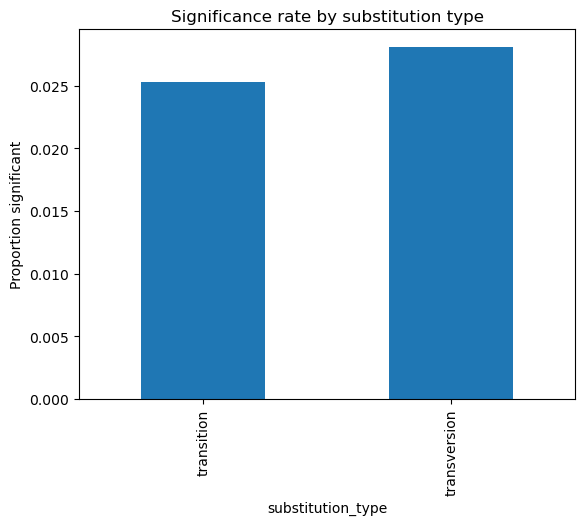

In [34]:
import pandas as pd

cont1 = pd.crosstab(
    variant_effect_df["substitution_type"],
    variant_effect_df["NGN2_variant_is_significant"],
)
print(cont1)

from scipy.stats import fisher_exact


table = cont1.values
oddsratio, p = fisher_exact(table)
print(f"Fisher exact test: OR: {oddsratio}, p: {p}")

sig_prop = variant_effect_df.groupby("substitution_type")[
    "NGN2_variant_is_significant"
].mean()

sig_prop.plot(
    kind="bar",
    ylabel="Proportion significant",
    title="Significance rate by substitution type",
)

NGN2_variant_is_significant  False  True 
substitution_type                        
transition                   14227    342
transversion                  6499    148
Fisher exact test: 0.9473324281108475 0.6222678673839821


<Axes: title={'center': 'Significance rate by substitution type'}, xlabel='substitution_type', ylabel='Proportion significant'>

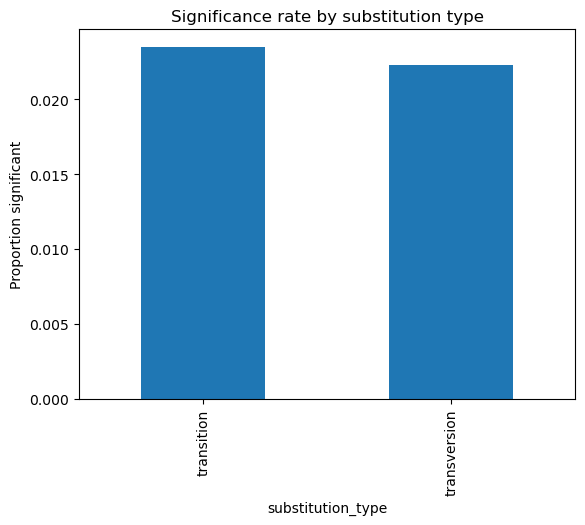

In [35]:
import pandas as pd

cont1 = pd.crosstab(
    variant_effect_df_fair["substitution_type"],
    variant_effect_df_fair["NGN2_variant_is_significant"],
)
print(cont1)

from scipy.stats import fisher_exact


table = cont1.values
oddsratio, p = fisher_exact(table)
print("Fisher exact test:", oddsratio, p)

sig_prop = variant_effect_df_fair.groupby("substitution_type")[
    "NGN2_variant_is_significant"
].mean()

sig_prop.plot(
    kind="bar",
    ylabel="Proportion significant",
    title="Significance rate by substitution type",
)

In [ ]:
chosen_order = [
    "very common",
    "common",
    "rare",
    "singleton",
]

chosen_palette = "viridis"  # "magma"

significant_threshold = 0.1
fontsize_ticks = 12
fontsize_label = 14

In [37]:
# are transitions enriched in more rare variants compared to common variants?
order = chosen_order

cont2 = pd.crosstab(
    variant_effect_df["af_category"],
    variant_effect_df["substitution_type"],
).reindex(order)
print(cont2)

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(cont2)
print("Chi-square:", chi2, "p =", p)
# are transitions enriched in more rare variants compared to common variants?
order = chosen_order

cont2 = pd.crosstab(
    variant_effect_df_fair["af_category"],
    variant_effect_df_fair["substitution_type"],
).reindex(order)
print(cont2)

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(cont2)
print("Chi-square:", chi2, "p =", p)

substitution_type  transition  transversion
af_category                                
very common              6995          3052
common                   5563          2514
rare                     6737          3514
singleton                5993          4316
Chi-square: 363.11450061509515 p = 2.1569546987737865e-78
substitution_type  transition  transversion
af_category                                
very common              6995          3052
common                   5563          2514
rare                     1048           486
singleton                 963           595
Chi-square: 38.56354785830898 p = 2.147403955667791e-08


In [38]:
# are transitions enriched in more rare variants compared to common variants?
order = chosen_order

cont2 = pd.crosstab(
    variant_effect_df["af_category"],
    variant_effect_df["is_cpg_transition"],
).reindex(order)
print(cont2)

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(cont2)
print("Chi-square:", chi2, "p =", p)
# are transitions enriched in more rare variants compared to common variants?
order = chosen_order

cont2 = pd.crosstab(
    variant_effect_df_fair["af_category"],
    variant_effect_df_fair["is_cpg_transition"],
).reindex(order)
print(cont2)

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(cont2)
print("Chi-square:", chi2, "p =", p)

is_cpg_transition  False  True 
af_category                    
very common         8503   1544
common              6578   1499
rare                8864   1387
singleton           9989    320
Chi-square: 1205.2824784769452 p = 5.236964054279751e-261
is_cpg_transition  False  True 
af_category                    
very common         8503   1544
common              6578   1499
rare                1264    270
singleton           1490     68
Chi-square: 202.79571314753 p = 1.0497014020106193e-43


/tmp/ipykernel_233722/2343563467.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tv_prop.index, y=tv_prop.values, palette=chosen_palette, width=0.3)


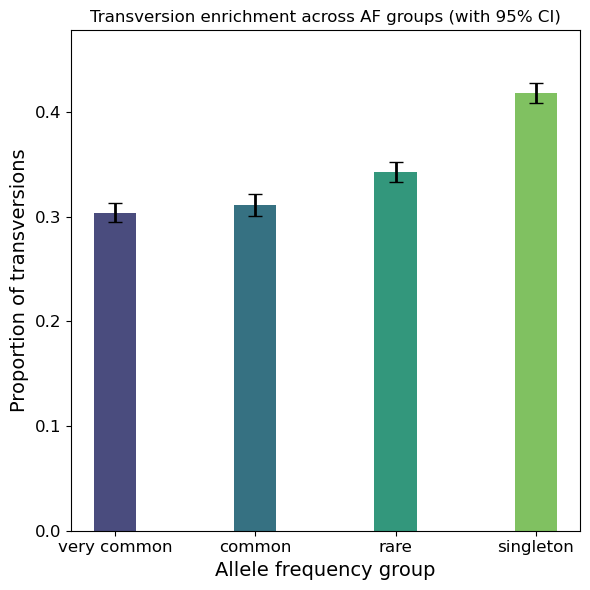

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

order = chosen_order


# Compute counts per AF group
counts = (
    variant_effect_df.groupby("af_category")["substitution_type"]
    .value_counts()
    .unstack()
    .reindex(order)
)

# Compute transversion proportions
tv_prop = counts["transversion"] / (counts["transition"] + counts["transversion"])

# Compute 95% Wilson confidence intervals
ci_low, ci_high = proportion_confint(
    count=counts["transversion"],
    nobs=(counts["transition"] + counts["transversion"]),
    alpha=0.05,
    method="wilson",
)

# Set up plot
plt.figure(figsize=(6, 6))
sns.barplot(x=tv_prop.index, y=tv_prop.values, palette=chosen_palette, width=0.3)

# Add error bars
plt.errorbar(
    x=range(len(tv_prop)),
    y=tv_prop.values,
    yerr=[tv_prop.values - ci_low, ci_high - tv_prop.values],
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=5,
)


plt.title("Transversion enrichment across AF groups (with 95% CI)")
plt.ylim(0, max(ci_high) + 0.05)
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.xlabel("Allele frequency group", fontsize=fontsize_label)
plt.ylabel("Proportion of transversions", fontsize=fontsize_label)
plt.tight_layout()
plt.show()

In [40]:
df_all = variant_effect_df.copy()
df_no_cpg = df_all[~df_all["is_cpg_transition"]].copy()

In [41]:
def compute_tv_prop(df, label):

    cont = pd.crosstab(df["af_category"], df["substitution_type"]).reindex(order)

    rows = []

    for af in order:

        total = cont.loc[af].sum()
        tv = cont.loc[af, "transversion"]

        prop = tv / total

        ci_low, ci_high = proportion_confint(tv, total, method="wilson")

        rows.append(
            {
                "af_category": af,
                "proportion": prop,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "dataset": label,
            }
        )

    return pd.DataFrame(rows)


tv_all = compute_tv_prop(df_all, "All variants")
tv_no_cpg = compute_tv_prop(df_no_cpg, "Excluding CpG transitions")

tv_df = pd.concat([tv_all, tv_no_cpg])

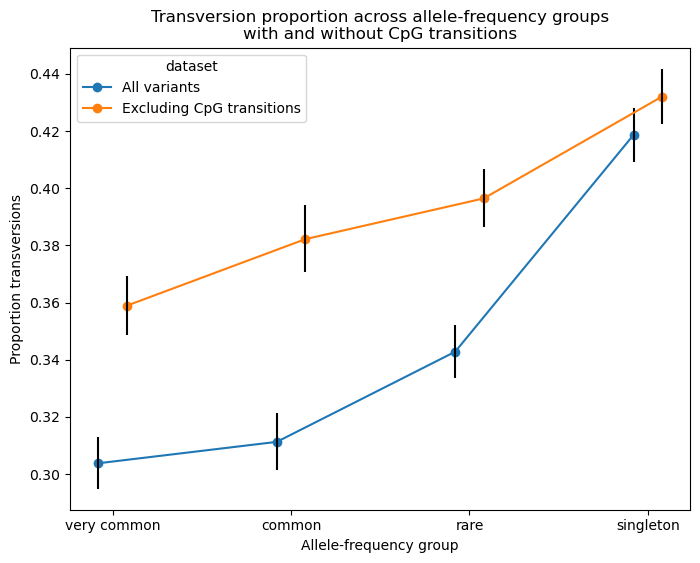

<Figure size 640x480 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# numeric x positions
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8, 6))

datasets = tv_df["dataset"].unique()

offset = 0.08  # horizontal separation between the two lines

for i, dataset in enumerate(datasets):

    sub = tv_df[tv_df["dataset"] == dataset].set_index("af_category").loc[order]

    y = sub["proportion"].values
    ylow = sub["ci_low"].values
    yhigh = sub["ci_high"].values

    x_shift = x + (-offset if i == 0 else offset)

    ax.plot(x_shift, y, marker="o", label=dataset)

    ax.vlines(x_shift, ylow, yhigh, color="black", linewidth=1.5)

# formatting
ax.set_xticks(x)
ax.set_xticklabels(order)

ax.set_ylabel("Proportion transversions")
ax.set_xlabel("Allele-frequency group")

ax.set_title(
    "Transversion proportion across allele-frequency groups\n"
    "with and without CpG transitions"
)

ax.legend(title="dataset")

# write to file as png and svg
output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/transition_transversion"
writing = True
if writing:
    file_name = os.path.join(
        output_path, "fraction_significant_by_AF_transition_transversion_with_C2G_transition"
    )
    plt.savefig(file_name + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(file_name + ".svg", dpi=300, bbox_inches="tight")


plt.show()

plt.tight_layout()
plt.show()

In [43]:
print(tv_df.to_string(index=False))

af_category  proportion   ci_low  ci_high                   dataset
very common    0.303772 0.294856 0.312838              All variants
     common    0.311254 0.301248 0.321439              All variants
       rare    0.342796 0.333668 0.352041              All variants
  singleton    0.418663 0.409172 0.428215              All variants
very common    0.358932 0.348802 0.369190 Excluding CpG transitions
     common    0.382183 0.370512 0.393991 Excluding CpG transitions
       rare    0.396435 0.386299 0.406661 Excluding CpG transitions
  singleton    0.432075 0.422389 0.441814 Excluding CpG transitions


In [44]:
from scipy.stats import chi2_contingency

cont = pd.crosstab(df_all["af_category"], df_all["substitution_type"])
chi2, p, _, _ = chi2_contingency(cont)

print("All variants:", p)

cont = pd.crosstab(df_no_cpg["af_category"], df_no_cpg["substitution_type"])
chi2, p, _, _ = chi2_contingency(cont)

print("No CpG:", p)

All variants: 2.1569546987737865e-78
No CpG: 2.4777451884149288e-23


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import fisher_exact

df = variant_effect_df.copy()
order = chosen_order

prop_df = (
    df.groupby(["af_category", "substitution_type"])["NGN2_variant_is_significant"]
    .agg(["sum", "count"])
    .reset_index()
)

prop_df["proportion"] = prop_df["sum"] / prop_df["count"]

ci_low, ci_high = proportion_confint(prop_df["sum"], prop_df["count"], method="wilson")

prop_df["ci_low"] = ci_low
prop_df["ci_high"] = ci_high

In [46]:
pvals = {}

for group in order:

    sub = df[df["af_category"] == group]

    table = pd.crosstab(sub["substitution_type"], sub["NGN2_variant_is_significant"])

    odds, p = fisher_exact(table)

    pvals[group] = p

print(pvals)

{'very common': 1.0, 'common': np.float64(0.4505660259558044), 'rare': np.float64(0.44761694593434054), 'singleton': np.float64(0.03434440006645953)}


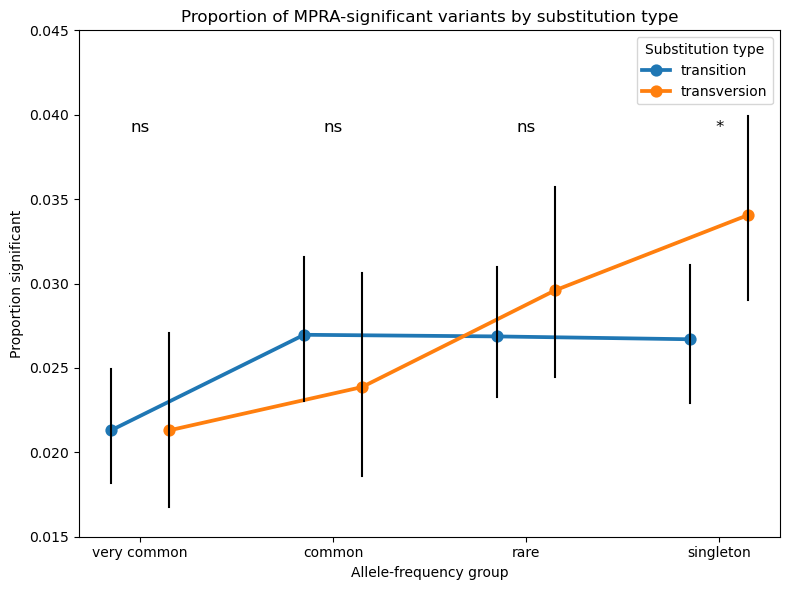

In [47]:
plt.figure(figsize=(8, 6))

sns.pointplot(
    data=prop_df,
    x="af_category",
    y="proportion",
    hue="substitution_type",
    order=order,
    dodge=0.3,
    errorbar=None,
)

# add Wilson CI
for _, row in prop_df.iterrows():

    x = order.index(row["af_category"]) + (
        0.15 if row["substitution_type"] == "transversion" else -0.15
    )

    plt.plot([x, x], [row["ci_low"], row["ci_high"]], color="black", linewidth=1.5)

# annotate significance
for i, group in enumerate(order):

    p = pvals[group]

    if p < 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        star = "ns"

    plt.text(i, 0.039, star, ha="center", fontsize=12)

plt.title("Proportion of MPRA-significant variants by substitution type")
plt.ylabel("Proportion significant")
plt.xlabel("Allele-frequency group")
plt.ylim(0.015, 0.045)

plt.legend(title="Substitution type")
plt.tight_layout()
plt.show()

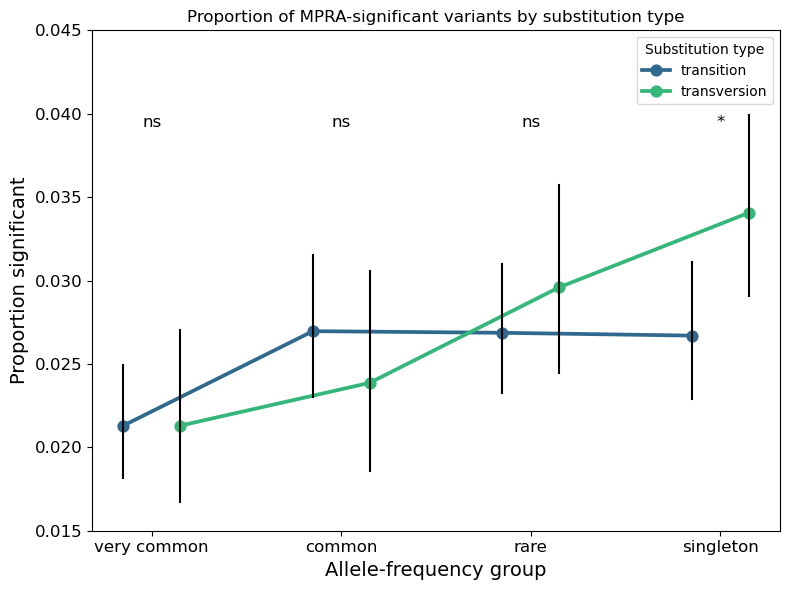

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

order = chosen_order
# df = variant_effect_df_tested_readout_fair.copy()
df = variant_effect_df.copy()

# Compute significance proportions for each (AF group × substitution type)
prop_df = (
    df.groupby(["af_category", "substitution_type"])["NGN2_variant_is_significant"]
    .agg(["sum", "count"])
    .reset_index()
)

prop_df["proportion"] = prop_df["sum"] / prop_df["count"]

# Compute Wilson CIs
ci_low, ci_high = proportion_confint(
    count=prop_df["sum"], nobs=prop_df["count"], method="wilson"
)

prop_df["ci_low"] = ci_low
prop_df["ci_high"] = ci_high

# Plot
plt.figure(figsize=(8, 6))
sns.pointplot(
    data=prop_df,
    x="af_category",
    y="proportion",
    hue="substitution_type",
    order=order,
    dodge=0.3,
    palette=chosen_palette,
    errorbar=None,
)

# Add CI whiskers manually
for i, row in prop_df.iterrows():
    x = order.index(row["af_category"]) + (
        0.15 if row["substitution_type"] == "transversion" else -0.15
    )
    plt.plot([x, x], [row["ci_low"], row["ci_high"]], color="black", linewidth=1.5)

from scipy.stats import mannwhitneyu

plt.title("Proportion of MPRA-significant variants by substitution type")
plt.ylabel("Proportion significant", fontsize=fontsize_label)
plt.xlabel("Allele-frequency group", fontsize=fontsize_label)
# plt.ylim(0, prop_df["ci_high"].max() + 0.05)
plt.legend(title="Substitution type")
# annotate with p-values from MWU test as stars:
for i, group in enumerate(order):
    sub = df[df["af_category"] == group]
    ts = sub[sub["substitution_type"] == "transition"]["NGN2_variant_abs_logFC"]
    tv = sub[sub["substitution_type"] == "transversion"]["NGN2_variant_abs_logFC"]
    stat, p = mannwhitneyu(tv, ts, alternative="greater")
    if p < 0.001:
        star = "***"
    elif p < 0.01:
        star = "**"
    elif p < 0.05:
        star = "*"
    else:
        star = "ns"
    # position above the highest CI
    y_pos = 0.039
    plt.text(i, y_pos, star, ha="center", va="bottom", fontsize=12)
# set fontsize
plt.xticks(fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
plt.ylim(0.015, 0.045)
plt.tight_layout()

# write to file as png and svg
output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/09_mpra_manuscript/figures/raw/transition_transversion"
writing=True
if writing:
    file_name = os.path.join(output_path, "fraction_significant_by_AF_transition_transversion")
    plt.savefig(
        file_name + ".png", dpi=300, bbox_inches="tight"
    )
    plt.savefig(
        file_name + ".svg", dpi=300, bbox_inches="tight"
    )


plt.show()